## SWE - CppJIT - CUB - SOLUTION

NumPy, JAX, PyOMP, and nanobind each rewrote the same step in a different way,
but nanobind required a separate build: edit the C++, run CMake, restart the
kernel, re-import. CppJIT removes that round-trip: hand it C++ or CUDA source
with `cppjit.cppdef`, and the declared functions are callable from Python
straight away. NumPy arrays can be passed as pointers with no wrapper code.
In this notebook we write the step as a CUB kernel and run the whole solve on the GPU.

**SOLUTION**

### Table of Contents

1. [Imports and activation](#sec1)
2. [Solve on the GPU with CUB in C++](#sec2)
3. [Acceptance and timing](#sec3)
4. [CuPy baseline](#sec4)
5. [Fusing the CuPy step](#sec5)
6. [CUDA C++ kernel](#sec6)
7. [Scaling: fused vs drop-in vs CPU](#sec7)
8. [Limitations and recap](#sec8)

### <a id="sec1"></a>1. Imports and activation

`import cppjit` starts a live CUDA-enabled clang-repl interpreter, so the kernels below run on the GPU.

---

**Quick Docs**

- `cppjit.cppdef(src)`: compile a block of C++ or CUDA source and link it into
  the session. The functions it declares become callable from Python automatically through proxies.
- `cppjit.gbl.<name>(...)`: call a declared C++ function. A contiguous `float64`
  array can be passed through as a `double*`, zero-copy.
- `cppjit.CUDA_ENABLED`: returns `True` if the C++ interpreter was created with CUDA support.

---

**Note.** CppJIT is the successor project to the [cppyy](https://cppyy.readthedocs.io/en/latest/) Python/C++ bindings generator that originated from the field of high-energy physics.
Based on the LLVM compiler infrastructure and the [CppInterOp](https://github.com/compiler-research/CppInterOp) library, CppJIT enables automatic interoperability paradigms and advanced features such as GPU and C++23 support.
This tutorial image bootstraps an alpha version of this package, built from source. A beta release on PyPI is planned for late August 2026.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import swe_core
import cppjit

assert cppjit.CUDA_ENABLED, \
    'This notebook needs the CUDA-enabled tutorial image.'

# Shared problem parameters.
N, N_STEPS = swe_core.canonical_size()
L       = 10.0
H0      = 1.0
AMP     = 0.1
SIG     = 0.5
CFL     = 0.4
G       = 9.81

# Float64 NumPy reference for validation.
h_ref, _ = swe_core.solve_numpy(N, N_STEPS)

# Host-side setup is built once per size, so the timed region is the solve.
def _setup_ic(n):
    h, hu = swe_core.bump_ic(n, L=L, h0=H0, amplitude=AMP, sigma=SIG)
    return np.ascontiguousarray(h), np.ascontiguousarray(hu)

setup_ic = swe_core.by_size(_setup_ic)


### <a id="sec2"></a>2. Solve on the GPU with CUB in C++

Let's solve the same Rusanov step with the CUB library in C++. CUB is a library of architecture-tuned CUDA C++ building blocks: warp-, block-,
and device-level algorithm primitives, shipped with the CUDA Toolkit as part
of CCCL.
The kernel lives in `swe_cub_solver.cpp`. `cppjit.cppdef` compiles it into the session.

---

**Quick Docs**

- `cub::DeviceFor::Bulk(n, op)`: run `op` on the GPU for each index in
  `0..n-1`, so we walk the cells without building an index array.
- `[=] __device__ (long i) { ... }`: a CUDA lambda. It captures the field
  pointers by value and runs on the device.
- `cudaMalloc` / `cudaMemcpy`: explicit device allocation and host-device
  copies.

In [2]:
cppjit.cppdef(open(swe_core.SWE_CUB_CPP).read())

def run_swe_gpu(n_cells=N, n_steps=N_STEPS):
    """Time-step on the GPU. The state stays in device memory."""
    cell_dx = L / n_cells
    step_dt = swe_core.fixed_dt(H0 + AMP, cell_dx, cfl=CFL, g=G)
    h, hu = setup_ic(n_cells)
    cppjit.gbl.gpu_swe_init(h, hu, h.shape[0])   # no-op once resident
    cppjit.gbl.gpu_swe_steps(cell_dx, step_dt, G, n_steps)


def fetch_swe_gpu(n_cells=N):
    """Final (h, hu) of the last solve, copied to the host."""
    h_out, hu_out = np.empty(n_cells + 2), np.empty(n_cells + 2)
    cppjit.gbl.gpu_swe_fetch(h_out, hu_out)
    return h_out, hu_out

### <a id="sec3"></a>3. Acceptance and timing

We run the full solve, check it against the float64 NumPy reference, then
report a time. Cold call cost: clang-repl emits PTX, and the CUDA driver compiles PTX to SASS for this GPU at first launch. Both the cold call and the warm median are saved to `timings.json`.

In [3]:
t0 = time.perf_counter()
run_swe_gpu()
cold_s = time.perf_counter() - t0
h_gpu, _ = fetch_swe_gpu()

warm = swe_core.timed_run(run_swe_gpu, warmup=2, repeats=5, label='12_cppjit_gpu_cub')
diff = swe_core.max_diff(h_ref, h_gpu)
swe_core.report_and_verify(warm, diff, tol=1e-12, cold_s=cold_s,
                           n=N, steps=N_STEPS,
                           cold_note='incl. JIT + first PTX->SASS')

swe_core.save_timing(
    warm, grid_str=f'N={N}', tool='cppjit_gpu_cub', hardware='gpu',
    dtype='float64', steps=N_STEPS, cold_s=cold_s, max_diff_vs_numpy=diff)

[12_cppjit_gpu_cub] N=4194304 steps=47 | cold   212.2 ms (incl. JIT + first PTX->SASS) | warm     5.5 ms | max_diff 1.11e-15 < tol 1e-12 | PASS


### <a id="sec4"></a>4. CuPy baseline

Since we are now running on GPU, let's use CuPy as a baseline. It runs the same vectorised step as `swe_core.step_numpy`, but on the device, as a drop-in replacement (`cp.op` for `np.op`).

**Q:** the warm time below lands far behind the CUB solve, on the same GPU
with the same arithmetic. Where does the time go? Count the kernel launches
per step with `nsys` below.

In [4]:
import cupy as cp

def step_cupy(h, hu, cell_dx, step_dt, g=G, tol=swe_core.DRY_TOL):
    """swe_core.step_numpy, slice for slice, on the device."""
    hL, hR   = h[:-1],  h[1:]
    huL, huR = hu[:-1], hu[1:]
    h_safe_L = cp.maximum(hL, tol)
    h_safe_R = cp.maximum(hR, tol)
    uL, uR = huL / h_safe_L,        huR / h_safe_R
    cL, cR = cp.sqrt(g * h_safe_L), cp.sqrt(g * h_safe_R)
    a      = cp.maximum(cp.abs(uL) + cL, cp.abs(uR) + cR)
    F_h  = 0.5 * (huL + huR)                            - 0.5 * a * (hR  - hL)
    F_hu = 0.5 * (huL*uL + 0.5*g*hL*hL
                + huR*uR + 0.5*g*hR*hR)                 - 0.5 * a * (huR - huL)
    h_new, hu_new = h.copy(), hu.copy()
    h_new[1:-1]  = h[1:-1]  - (step_dt / cell_dx) * (F_h[1:]  - F_h[:-1])
    hu_new[1:-1] = hu[1:-1] - (step_dt / cell_dx) * (F_hu[1:] - F_hu[:-1])
    return h_new, hu_new

setup_ic_dev = swe_core.by_size(lambda n: tuple(cp.asarray(a) for a in setup_ic(n)))


def run_swe_cupy(n_cells=N, n_steps=N_STEPS):
    """Full solve with CuPy. The state is already on the device."""
    cell_dx = L / n_cells
    step_dt = swe_core.fixed_dt(H0 + AMP, cell_dx, cfl=CFL, g=G)
    h0, hu0 = setup_ic_dev(n_cells)
    h, hu = h0.copy(), hu0.copy()
    for _ in range(n_steps):
        h[0]  =  h[1];   h[-1]  =  h[-2]
        hu[0] = -hu[1];  hu[-1] = -hu[-2]
        h, hu = step_cupy(h, hu, cell_dx, step_dt)
    cp.cuda.Device().synchronize()
    return h, hu

t0 = time.perf_counter()
h_cupy, _ = run_swe_cupy()
cold_cupy_s = time.perf_counter() - t0

warm_cupy = swe_core.timed_run(run_swe_cupy, warmup=2, repeats=5, label='12_cupy')
diff_cupy = swe_core.max_diff(h_ref, cp.asnumpy(h_cupy))
swe_core.report_and_verify(warm_cupy, diff_cupy, tol=1e-12, cold_s=cold_cupy_s,
                           n=N, steps=N_STEPS,
                           cold_note='incl. NVRTC kernel compiles')

swe_core.save_timing(
    warm_cupy, grid_str=f'N={N}', tool='cupy', hardware='gpu',
    dtype='float64', steps=N_STEPS, cold_s=cold_cupy_s,
    max_diff_vs_numpy=diff_cupy)


[12_cupy] N=4194304 steps=47 | cold    87.6 ms (incl. NVRTC kernel compiles) | warm    54.1 ms | max_diff 0.00e+00 < tol 1e-12 | PASS


**Note.** The cold call doesn't actually compile anything. NVRTC builds CuPy's
own operator kernels (such as `cupy_sqrt__float64...`), and the cubins land
in an on-disk cache (`CUPY_CACHE_DIR`) that persists across sessions, so a
warm cache hides the compile cost. To record it, point `CUPY_CACHE_DIR` at an
empty directory before the `cupy` import and re-run.

**Count the kernel launches.** This tutorial image ships Nsight Systems. The cell
below profiles a short solve of each GPU path and sums kernel instances
per step.

---

**Quick Docs**

- `nsys profile -o <name> python script.py`: record a timeline;
  `--python-sampling=true` adds interpreter backtraces.
- `nsys stats --report cuda_gpu_kern_sum <name>.nsys-rep`: kernel
  instance counts per name.

In [5]:
%%writefile swe_launch_probe.py
import sys
import time

import cupy as cp
import swe_core

mode, N, steps = sys.argv[1], int(sys.argv[2]), int(sys.argv[3])
L = 10.0; dx = L / N; dt = swe_core.fixed_dt(1.1, dx)
h, hu = swe_core.bump_ic(N, L=L)

if mode in ('cub', 'raw'):
    import cppjit
    assert cppjit.CUDA_ENABLED
    cppjit.cppdef(open(swe_core.SWE_CUB_CPP if mode == 'cub'
                       else swe_core.SWE_RAW_CPP).read())
    tag = '' if mode == 'cub' else '_raw'
    getattr(cppjit.gbl, 'gpu_swe_init' + tag)(h, hu, h.shape[0])
    step = getattr(cppjit.gbl, 'gpu_swe_steps' + tag)
    solve = lambda: step(dx, dt, 9.81, steps)
elif mode == 'jax':
    import jax
    import jax.numpy as jnp
    from swe_jax_step import solve64
    st = tuple(jnp.asarray(a) for a in (h, hu))

    def solve():
        jax.block_until_ready(solve64(st, dx, dt, steps))
elif mode == 'fused':
    import swe_fused_kernel as k
    step = cp.ElementwiseKernel(
        'raw float64 h, raw float64 hu, int64 n, float64 inv, float64 g',
        'raw float64 h_new, raw float64 hu_new',
        k.BODY, 'swe_step_fused', preamble=k.PREAMBLE)
    a0, b0 = cp.asarray(h), cp.asarray(hu)
    a, b = cp.empty_like(a0), cp.empty_like(b0)
    c, d = cp.empty_like(a0), cp.empty_like(b0)
    inv = dt / dx

    def solve():
        p, q, r, s = a, b, c, d
        cp.copyto(p, a0); cp.copyto(q, b0)
        for _ in range(steps):
            step(p, q, N, inv, 9.81, r, s, size=N)
            p, q, r, s = r, s, p, q
        cp.cuda.Device().synchronize()
else:
    gh0, ghu0 = cp.asarray(h), cp.asarray(hu)

    def solve():
        gh, ghu = gh0.copy(), ghu0.copy()
        for _ in range(steps):
            gh[0] = gh[1]; gh[-1] = gh[-2]; ghu[0] = -ghu[1]; ghu[-1] = -ghu[-2]
            hL, hR = gh[:-1], gh[1:]; huL, huR = ghu[:-1], ghu[1:]
            hsL = cp.maximum(hL, 1e-6); hsR = cp.maximum(hR, 1e-6)
            uL, uR = huL / hsL, huR / hsR
            cL, cR = cp.sqrt(9.81 * hsL), cp.sqrt(9.81 * hsR)
            a = cp.maximum(cp.abs(uL) + cL, cp.abs(uR) + cR)
            F_h = 0.5 * (huL + huR) - 0.5 * a * (hR - hL)
            F_hu = (0.5 * (huL*uL + 0.5*9.81*hL*hL + huR*uR + 0.5*9.81*hR*hR)
                    - 0.5 * a * (huR - huL))
            gh2, ghu2 = gh.copy(), ghu.copy()
            gh2[1:-1]  = gh[1:-1]  - (dt/dx) * (F_h[1:]  - F_h[:-1])
            ghu2[1:-1] = ghu[1:-1] - (dt/dx) * (F_hu[1:] - F_hu[:-1])
            gh, ghu = gh2, ghu2
        cp.cuda.Device().synchronize()

# One warm call pays the compile and the allocation, then profile the next one.
solve()
cp.cuda.profiler.start()
t0 = time.perf_counter()
solve()
cp.cuda.Device().synchronize()
print(f'WALL_S {time.perf_counter() - t0:.6f}')
cp.cuda.profiler.stop()


Writing swe_launch_probe.py


In [6]:
PROF_STEPS = 20
MODES = ('cub', 'raw', 'cupy')
STAGE = {'cub': '12_cppjit_gpu_cub', 'raw': '12_cppjit_gpu_raw',
         'cupy': '12_cupy', 'fused': '12_cupy_fused',
         'jax': '09_jax_fp64'}
walls = {}

# Node tracing records kernels inside CUDA graphs, which XLA uses.
for mode in MODES:
    out = !nsys profile -c cudaProfilerApi --capture-range-end=stop --cuda-graph-trace=node --force-overwrite true -o launch_{mode} python swe_launch_probe.py {mode} {N} {PROF_STEPS}
    walls[mode] = float(next(l for l in out if 'WALL_S' in l).split()[1])


In [7]:
for mode in MODES:
    rows = !nsys stats --force-export=true --report cuda_gpu_kern_sum launch_{mode}.nsys-rep
    kern = [ln for ln in rows if ln.strip()[:1].isdigit()]
    total = sum(int(ln.split()[2]) for ln in kern)
    if total == 0:
        raise RuntimeError(f'no kernels recorded for {mode}; re-run the profile cell')
    print(f'  {mode:>6}: {total:>4} kernel launches over {PROF_STEPS} steps '
          f'= {total / PROF_STEPS:5.1f} kernels/step')


     cub:   40 kernel launches over 20 steps =   2.0 kernels/step


     raw:   40 kernel launches over 20 steps =   2.0 kernels/step


    cupy:  862 kernel launches over 20 steps =  43.1 kernels/step


### <a id="sec5"></a>5. Fusing the CuPy step

`cupy.ElementwiseKernel` fuses the whole step into one CUDA C kernel,
one thread per cell. Each thread derives its ghost values, computes
its two face fluxes, and writes its update. This gives us one launch
per step, with no Python round-trip. Since neighbouring cells share faces,
every interior flux is computed twice. Storing them instead would require a
second pass and launch, as in the earlier CUB case.

---

**Quick Docs**

- `cp.ElementwiseKernel(in_params, out_params, operation, name, preamble=...)`:
  compiles a CUDA C elementwise kernel on first call (NVRTC). `raw float64 x`
  passes an array with explicit indexing (`x[j]`) instead of an implicit
  per-element view; `size=` sets the launch size.
- `preamble`: pass CUDA C `__device__` helpers.

In [8]:
_RUSANOV_DEV = r'''
__device__ void rusanov_face(double hL, double hR, double huL, double huR,
                             double g, double& Fh, double& Fhu) {
    const double DRY  = 1e-6;
    const double hL_s = hL > DRY ? hL : DRY;
    const double hR_s = hR > DRY ? hR : DRY;
    const double uL = huL / hL_s, uR = huR / hR_s;
    const double cL = sqrt(g * hL_s), cR = sqrt(g * hR_s);
    const double a  = fmax(fabs(uL) + cL, fabs(uR) + cR);
    Fh  = 0.5 * (huL + huR) - 0.5 * a * (hR - hL);
    Fhu = 0.5 * (huL * uL + 0.5 * g * hL * hL + huR * uR + 0.5 * g * hR * hR)
        - 0.5 * a * (huR - huL);
}
'''

_FUSED_BODY = r'''
    const long j = i + 1;                              // interior cell
    const double hW  = (j == 1) ?  h[1]  : h[j - 1];   // reflective ghosts,
    const double huW = (j == 1) ? -hu[1] : hu[j - 1];  // derived in-kernel
    const double hE  = (j == n) ?  h[n]  : h[j + 1];
    const double huE = (j == n) ? -hu[n] : hu[j + 1];
    double Fw_h, Fw_hu, Fe_h, Fe_hu;
    rusanov_face(hW,   h[j], huW,   hu[j], g, Fw_h, Fw_hu);
    rusanov_face(h[j], hE,   hu[j], huE,   g, Fe_h, Fe_hu);
    h_new[j]  = h[j]  - inv * (Fe_h  - Fw_h);
    hu_new[j] = hu[j] - inv * (Fe_hu - Fw_hu);
    if (j == 1) { h_new[0] = h[1]; hu_new[0] = -hu[1]; }
    if (j == n) { h_new[n + 1] = h[n]; hu_new[n + 1] = -hu[n]; }
'''

step_cupy_fused = cp.ElementwiseKernel(
    'raw float64 h, raw float64 hu, int64 n, float64 inv, float64 g',
    'raw float64 h_new, raw float64 hu_new',
    _FUSED_BODY, 'swe_step_fused', preamble=_RUSANOV_DEV)

# The profiler runs this kernel in its own process, so write the two sources
# out rather than keeping a second copy of them.
open('swe_fused_kernel.py', 'w').write(
    f"PREAMBLE = r'''{_RUSANOV_DEV}'''\nBODY = r'''{_FUSED_BODY}'''\n")

# Device buffers are allocated once and reset to the initial condition per call.
def _setup_ic_fused(n):
    h0, hu0 = setup_ic_dev(n)
    return h0, hu0, *(cp.empty_like(h0) for _ in range(4))

setup_ic_fused = swe_core.by_size(_setup_ic_fused)


def run_swe_cupy_fused(n_cells=N, n_steps=N_STEPS):
    """Full solve with hand-fused CuPy kernel: one launch per step."""
    cell_dx = L / n_cells
    step_dt = swe_core.fixed_dt(H0 + AMP, cell_dx, cfl=CFL, g=G)
    h0, hu0, h, hu, h2, hu2 = setup_ic_fused(n_cells)
    cp.copyto(h, h0)
    cp.copyto(hu, hu0)
    inv = step_dt / cell_dx
    for _ in range(n_steps):
        step_cupy_fused(h, hu, n_cells, inv, G, h2, hu2, size=n_cells)
        h, hu, h2, hu2 = h2, hu2, h, hu
    cp.cuda.Device().synchronize()
    return h, hu

t0 = time.perf_counter()
h_fused, _ = run_swe_cupy_fused()
cold_fused_s = time.perf_counter() - t0

warm_fused = swe_core.timed_run(run_swe_cupy_fused, warmup=2, repeats=5,
                                label='12_cupy_fused')
diff_fused = swe_core.max_diff(h_ref, cp.asnumpy(h_fused))
swe_core.report_and_verify(warm_fused, diff_fused, tol=1e-12, cold_s=cold_fused_s,
                           n=N, steps=N_STEPS,
                           cold_note='incl. NVRTC compile of fused kernel')

swe_core.save_timing(
    warm_fused, grid_str=f'N={N}', tool='cupy_fused', hardware='gpu',
    dtype='float64', steps=N_STEPS, cold_s=cold_fused_s,
    max_diff_vs_numpy=diff_fused)


[12_cupy_fused] N=4194304 steps=47 | cold    91.0 ms (incl. NVRTC compile of fused kernel) | warm     3.5 ms | max_diff 1.11e-15 < tol 1e-12 | PASS


### <a id="sec6"></a>6. CUDA C++ kernel

CppJIT is not tied to CUB: the same session can declare a `__global__`
kernel and launch it directly. `swe_raw_cuda_solver.cpp` rewrites our GPU solver in CUDA C++.

The raw launch comes with trade-offs: you have to size the launch yourself, write the
index guard, and give up CUB's algorithm libraries, autotuning and abstractions.

---

**Quick Docs**

- `__global__ void kernel(...)`: a CUDA C++ kernel; each thread computes its index
  from `blockIdx`/`blockDim`/`threadIdx` and guards the range.
- `kernel<<<grid, block>>>(args)`: kernel launch syntax. cppjit
  compiles and registers the kernel live (same clang-repl session as CUB).
- Launch shape: 256-thread blocks, `grid = ceil(N / 256)`, try tuning if time permits.

In [9]:
# Load the CUDA C++ kernel into our Python session.
cppjit.cppdef(open(swe_core.SWE_RAW_CPP).read())

def run_swe_gpu_raw(n_cells=N, n_steps=N_STEPS):
    """Time-step with CUDA C++, two launches per step."""
    cell_dx = L / n_cells
    step_dt = swe_core.fixed_dt(H0 + AMP, cell_dx, cfl=CFL, g=G)
    h, hu = setup_ic(n_cells)
    cppjit.gbl.gpu_swe_init_raw(h, hu, h.shape[0])
    cppjit.gbl.gpu_swe_steps_raw(cell_dx, step_dt, G, n_steps)


def fetch_swe_gpu_raw(n_cells=N):
    """Final (h, hu) of the last raw solve."""
    h_out, hu_out = np.empty(n_cells + 2), np.empty(n_cells + 2)
    cppjit.gbl.gpu_swe_fetch_raw(h_out, hu_out)
    return h_out, hu_out

t0 = time.perf_counter()
run_swe_gpu_raw()
cold_raw_s = time.perf_counter() - t0
h_raw, _ = fetch_swe_gpu_raw()

warm_raw = swe_core.timed_run(run_swe_gpu_raw, warmup=2, repeats=5,
                              label='12_cppjit_gpu_raw')
diff_raw = swe_core.max_diff(h_ref, h_raw)
swe_core.report_and_verify(warm_raw, diff_raw, tol=1e-12, cold_s=cold_raw_s,
                           n=N, steps=N_STEPS,
                           cold_note='incl. JIT + first PTX->SASS compilation')

swe_core.save_timing(
    warm_raw, grid_str=f'N={N}', tool='cppjit_gpu_raw', hardware='gpu',
    dtype='float64', steps=N_STEPS, cold_s=cold_raw_s,
    max_diff_vs_numpy=diff_raw)


[12_cppjit_gpu_raw] N=4194304 steps=47 | cold    50.9 ms (incl. JIT + first PTX->SASS compilation) | warm     5.3 ms | max_diff 1.11e-15 < tol 1e-12 | PASS


### <a id="sec7"></a>7. Scaling: fused vs drop-in vs CPU

The sweep below times all five paths across grid sizes and plots throughput.

N=   262,144 steps= 762   CppJIT raw   28936   CppJIT CUB   28222   CuPy fused   36091   CuPy drop-in     721   NumPy (CPU)      71   Mcells/s


N= 1,048,576 steps= 190   CppJIT raw   40382   CppJIT CUB   36556   CuPy fused   56120   CuPy drop-in    2910   NumPy (CPU)      63   Mcells/s


N= 4,194,304 steps=  47   CppJIT raw   37167   CppJIT CUB   35894   CuPy fused   57715   CuPy drop-in    3643   NumPy (CPU)      38   Mcells/s


N=16,777,216 steps=  20   CppJIT raw   38685   CppJIT CUB   37057   CuPy fused   58225   CuPy drop-in    4088   NumPy (CPU)      31   Mcells/s


N=67,108,864 steps=  20   CppJIT raw   39068   CppJIT CUB   38291   CuPy fused   56873   CuPy drop-in    4223   Mcells/s


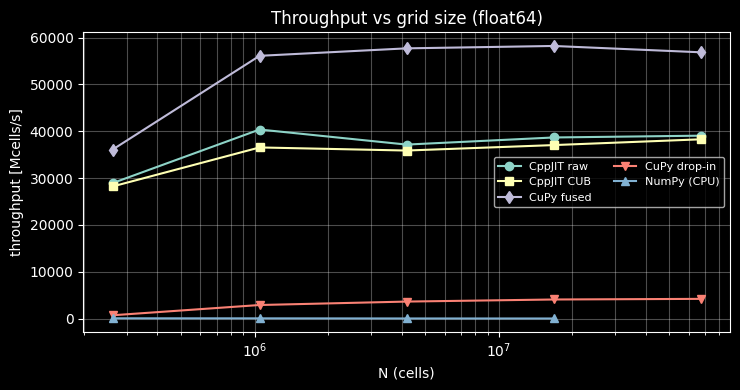

In [10]:
# Sweep the grid size and compare all five paths on throughput.
rates = swe_core.sweep_table({
    'CppJIT raw': run_swe_gpu_raw, 'CppJIT CUB': run_swe_gpu,
    'CuPy fused': run_swe_cupy_fused, 'CuPy drop-in': run_swe_cupy,
    'NumPy (CPU)': swe_core.solve_numpy})

swe_core.plot_rate_sweep([n for n, _ in swe_core.sweep_points()], rates,
                         'N (cells)', 'Throughput vs grid size (float64)',
                         logy=False)

In [11]:
# Rates across the shared size range, for the synthesis notebook (14).
for _stage, _fn in (('12_cppjit_gpu_cub', run_swe_gpu),
                    ('12_cppjit_gpu_raw', run_swe_gpu_raw),
                    ('12_cupy', run_swe_cupy),
                    ('12_cupy_fused', run_swe_cupy_fused)):
    swe_core.save_sweep(_stage, _fn)

In [12]:
# The fused kernel is defined above, so it is profiled here rather than with
# the others, then every path's wall clock is split the same way.
for extra in ('fused', 'jax'):
    out = !nsys profile -c cudaProfilerApi --capture-range-end=stop --cuda-graph-trace=node --force-overwrite true -o launch_{extra} python swe_launch_probe.py {extra} {N} {PROF_STEPS}
    walls[extra] = float(next(l for l in out if 'WALL_S' in l).split()[1])

for mode in (*MODES, 'fused', 'jax'):
    bd = swe_core.nsys_breakdown(f'launch_{mode}.nsys-rep', walls[mode])
    swe_core.save_breakdown(STAGE[mode], bd, N, PROF_STEPS)
    print(f"  {mode:>6}: kernels {100 * bd['kernel_s'] / bd['total_s']:4.1f}%   "
          f"copies {100 * bd['memcpy_s'] / bd['total_s']:4.1f}%   "
          f"host {100 * bd['host_s'] / bd['total_s']:4.1f}%")


     cub: kernels 91.5%   copies  1.7%   host  6.8%


     raw: kernels 91.7%   copies  1.7%   host  6.6%


    cupy: kernels 88.9%   copies  3.8%   host  7.2%
   fused: kernels 87.4%   copies  2.6%   host  9.9%


     jax: kernels 40.1%   copies 44.0%   host 15.9%


Takeaways:

- CuPy drop-in beats NumPy at every size and still trails the fused kernel.
  Each of its 43 kernels per step re-reads the arrays from memory; the
  fused kernel reads them once.
- The raw CUDA dispatch and the CUB path run within a few percent of each
  other. Both trail the fused CuPy kernel, which stores no fluxes.

### <a id="sec8"></a>8. Limitations and recap

CppJIT gives us C++ and CUDA as a notebook language: edit a cell, run it,
call it from Python. The main cost is compilation at first use: `cppdef`
parses the source when it is declared, and the first call includes JIT
compilation of both host and device code.

**Recap.**

- `cppjit.cppdef` compiles C++ and CUDA in the running session; `cppjit.gbl`
  allows function dispatch with NumPy arguments as pointers.
- The same Rusanov step runs on the GPU with CUB, the data kept resident
  across the time loop.
- The drop-in CuPy path beats NumPy at every size and still trails the fused
  paths. The win over drop-in is memory traffic: dozens of kernels per step
  each re-read the arrays, against one or two that read them once.
- The fused CuPy kernel is a source fragment compiled inside CuPy's generated
  wrapper; CppJIT compiles standard C++ translation units.

Next: `13__swe__mpi4py.ipynb` distributes the same solve across MPI ranks:
slab decomposition and halo exchange.